In [9]:
import pandas as pd
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
from google.colab import files

uploaded = files.upload()

Saving Sales_data (1).csv to Sales_data (1).csv


In [10]:
import pandas as pd
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
df.head()

,order_id,order_date,ship_date,customer,manufactory,product_name,segment,category,subcategory,region,zip,city,state,country,discount,profit,quantity,sales,profit_margin
0,US-2020-103800,1/3/2019,1/7/2019,Darren Powers,Message Book,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Consumer,Office Supplies,Paper,Central,77095,Houston,Texas,United States,0.2,5.5512,2,16.448,0.3375
1,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,GBC,GBC Standard Plastic Binding Systems Combs,Home Office,Office Supplies,Binders,Central,60540,Naperville,Illinois,United States,0.8,-5.4870,2,3.540,-1.5500
2,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,Avery,Avery 508,Home Office,Office Supplies,Labels,Central,60540,Naperville,Illinois,United States,0.2,4.2717,3,11.784,0.3625
3,US-2020-112326,1/4/2019,1/8/2019,Phillina Ober,SAFCO,SAFCO Boltless Steel Shelving,Home Office,Office Supplies,Storage,Central,60540,Naperville,Illinois,United States,0.2,-64.7748,3,272.736,-0.2375
4,US-2020-141817,1/5/2019,1/12/2019,Mick Brown,Avery,Avery Hi-Liter EverBold Pen Style Fluorescent ...,Consumer,Office Supplies,Art,East,19143,Philadelphia,Pennsylvania,United States,0.2,4.8840,3,19.536,0.2500


In [37]:
#checking the size of dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 9993
Columns: 19


In [38]:
# Seeing all column names
df.columns

Index(['order_id', 'order_date', 'ship_date', 'customer', 'manufactory',
       'product_name', 'segment', 'category', 'subcategory', 'region', 'zip',
       'city', 'state', 'country', 'discount', 'profit', 'quantity', 'sales',
       'profit_margin'],
      dtype='object')

In [16]:
# information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       9994 non-null   object 
 1   order_date     9994 non-null   object 
 2   ship_date      9994 non-null   object 
 3   customer       9994 non-null   object 
 4   manufactory    9994 non-null   object 
 5   product_name   9994 non-null   object 
 6   segment        9994 non-null   object 
 7   category       9994 non-null   object 
 8   subcategory    9994 non-null   object 
 9   region         9994 non-null   object 
 10  zip            9994 non-null   int64  
 11  city           9994 non-null   object 
 12  state          9994 non-null   object 
 13  country        9994 non-null   object 
 14  discount       9994 non-null   float64
 15  profit         9994 non-null   float64
 16  quantity       9994 non-null   int64  
 17  sales          9994 non-null   float64
 18  profit_m

In [17]:
# checking missing values
df.isnull().sum()


,0
order_id,0
order_date,0
ship_date,0
customer,0
manufactory,0
product_name,0
segment,0
category,0
subcategory,0
region,0


In [18]:
# Checking duplicate rows
df.duplicated().sum()

np.int64(1)

In [19]:
# Checking data types
df.dtypes

,0
order_id,object
order_date,object
ship_date,object
customer,object
manufactory,object
product_name,object
segment,object
category,object
subcategory,object
region,object


In [20]:
# Removing duplicated rows
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [21]:
print("Rows after cleaning:", len(df))

Rows after cleaning: 9993


In [22]:
# Checking important numerical columns

print("Sales:")
print("Minimum:", df["sales"].min())
print("Maximum:", df["sales"].max())

print("\nProfit:")
print("Minimum:", df["profit"].min())
print("Maximum:", df["profit"].max())

print("\nQuantity:")
print("Minimum:", df["quantity"].min())
print("Maximum:", df["quantity"].max())

print("\nDiscount:")
print("Minimum:", df["discount"].min())
print("Maximum:", df["discount"].max())

Sales:
Minimum: 0.444
Maximum: 22638.48

Profit:
Minimum: -6599.978
Maximum: 8399.976

Quantity:
Minimum: 1
Maximum: 14

Discount:
Minimum: 0.0
Maximum: 0.8


In [23]:
# Calculating Total Sales

total_sales = df["sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 2296919.4883


In [24]:
# Calculating Total Profit

total_profit = df["profit"].sum()
print("Total Profit:", total_profit)

Total Profit: 286409.08050000004


In [25]:
# Calculating Total Quantity Sold

total_quantity = df["quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 37871


In [26]:
# Calculating total unique orders

total_orders = df["order_id"].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


In [27]:
# Calculate Average Order Value

average_order_value = total_sales / total_orders
print("Average Order Value:", average_order_value)

Average Order Value: 458.55849237372723


In [28]:
# Sales by Category

sales_by_category = df.groupby("category")["sales"].sum()
print(sales_by_category)

category
Furniture          741718.4233
Office Supplies    719047.0320
Technology         836154.0330
Name: sales, dtype: float64


In [29]:
# Sorting categories from highest to lowest sales

sales_by_category = sales_by_category.sort_values(ascending=False)
print(sales_by_category)

category
Technology         836154.0330
Furniture          741718.4233
Office Supplies    719047.0320
Name: sales, dtype: float64


In [30]:
df.groupby("category")["sales"].sum()

,sales
category,
Furniture,741718.4233
Office Supplies,719047.0320
Technology,836154.0330


In [31]:
# Profit by Category

profit_by_category = df.groupby("category")["profit"].sum()
profit_by_category = profit_by_category.sort_values(ascending=False)
print(profit_by_category)

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18463.3316
Name: profit, dtype: float64


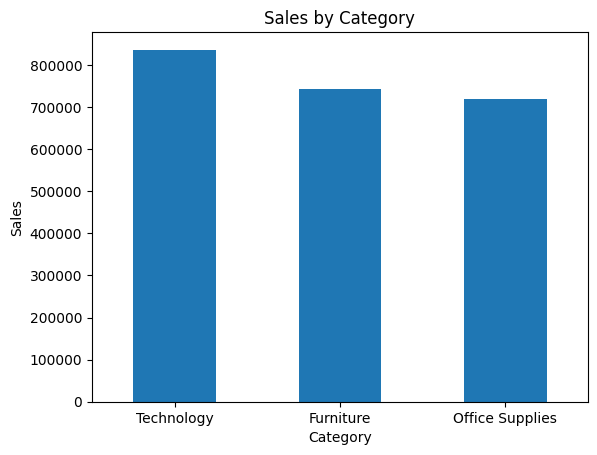

In [32]:
import matplotlib.pyplot as plt

sales_by_category.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

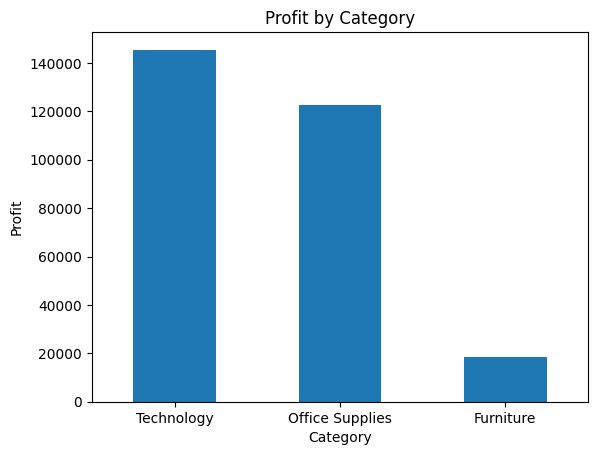

In [33]:
profit_by_category.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.xticks(rotation=0)
plt.show()

In [39]:
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

In [40]:
print(df["order_date"].dtype)

datetime64[ns]


In [41]:
df["month"] = df["order_date"].dt.to_period("M")
monthly_sales = df.groupby("month")["sales"].sum()
print(monthly_sales)

month
2019-01     14236.8950
2019-02      4519.8920
2019-03     55691.0090
2019-04     28013.9730
2019-05     23648.2870
2019-06     34595.1276
2019-07     33946.3930
2019-08     27909.4685
2019-09     81777.3508
2019-10     31453.3930
2019-11     78628.7167
2019-12     69545.6205
2020-01     18174.0756
2020-02     11951.4110
2020-03     38726.2520
2020-04     34195.2085
2020-05     30131.6865
2020-06     24797.2920
2020-07     28765.3250
2020-08     36898.3322
2020-09     64595.9180
2020-10     31404.9235
2020-11     75972.5635
2020-12     74919.5212
2021-01     18542.4910
2021-02     22978.8150
2021-03     51715.8750
2021-04     38750.0390
2021-05     56987.7280
2021-06     40344.5340
2021-07     39261.9630
2021-08     31115.3743
2021-09     73410.0249
2021-10     59687.7450
2021-11     79411.9658
2021-12     96999.0430
2022-01     43971.3740
2022-02     20301.1334
2022-03     58872.3528
2022-04     36521.5361
2022-05     44261.1102
2022-06     52981.7257
2022-07     45264.4160
2022-

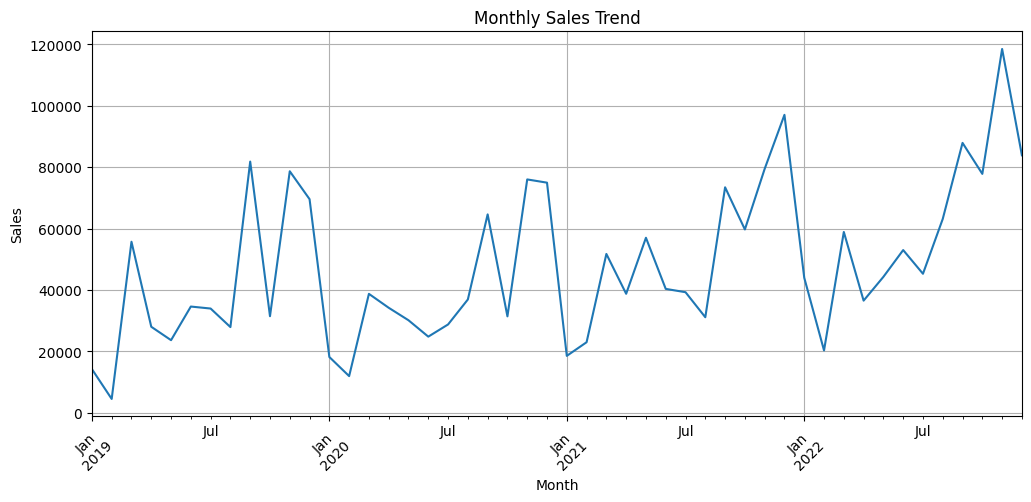

In [42]:
monthly_sales.plot(kind="line", figsize=(12, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [43]:
top_products = df.groupby("product_name")["sales"].sum()
top_products = top_products.sort_values(ascending=False).head(10)

print(top_products)

product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64


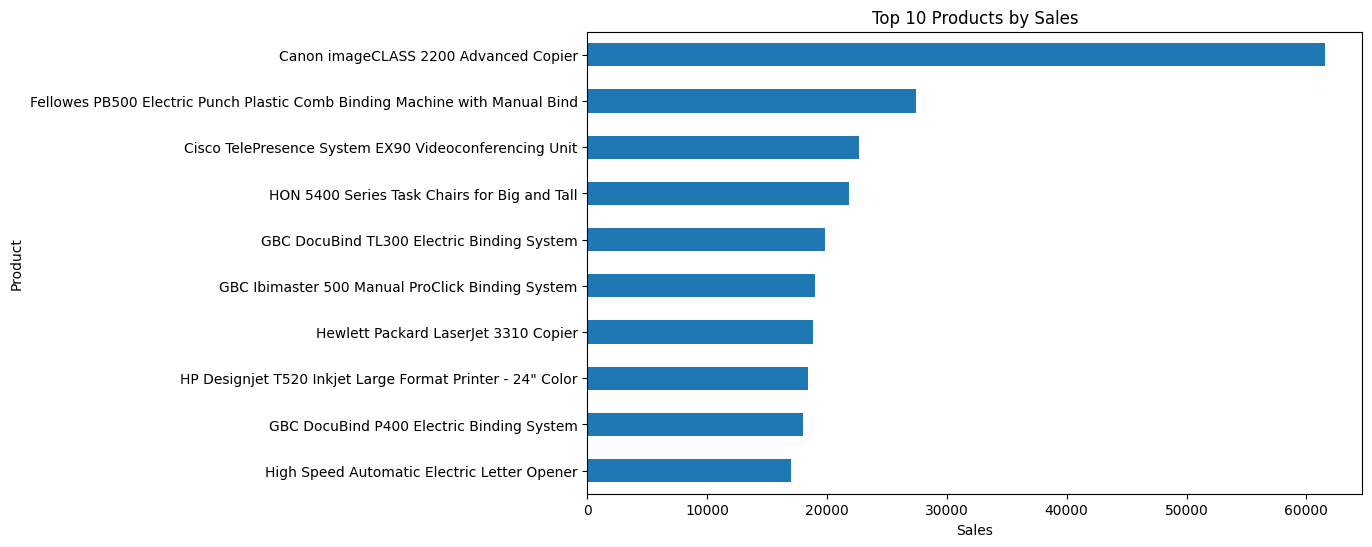

In [44]:
top_products.sort_values().plot(kind="barh", figsize=(10, 6))

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

In [45]:
sales_by_region = df.groupby("region")["sales"].sum()
sales_by_region = sales_by_region.sort_values(ascending=False)

print(sales_by_region)

region
West       725457.8245
East       678499.8680
Central    501239.8908
South      391721.9050
Name: sales, dtype: float64


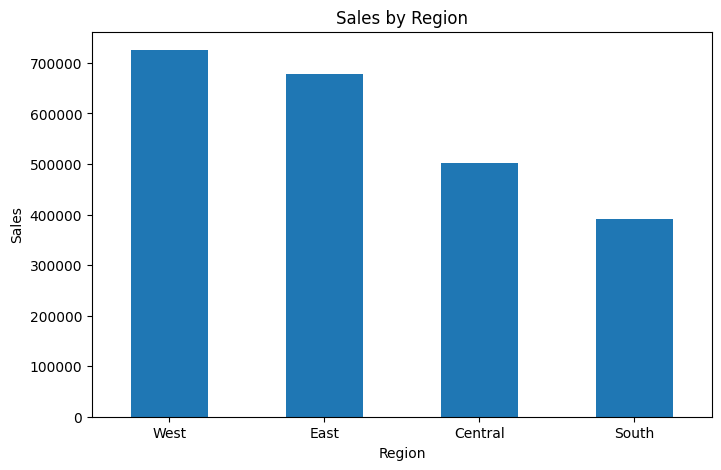

In [46]:
sales_by_region.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

In [47]:
profit_by_region = df.groupby("region")["profit"].sum()
profit_by_region = profit_by_region.sort_values(ascending=False)

print(profit_by_region)

region
West       108418.4489
East        91534.8388
South       46749.4303
Central     39706.3625
Name: profit, dtype: float64


In [48]:
profit_by_region = df.groupby("region")["profit"].sum()
profit_by_region = profit_by_region.sort_values(ascending=False)

print(profit_by_region)

region
West       108418.4489
East        91534.8388
South       46749.4303
Central     39706.3625
Name: profit, dtype: float64


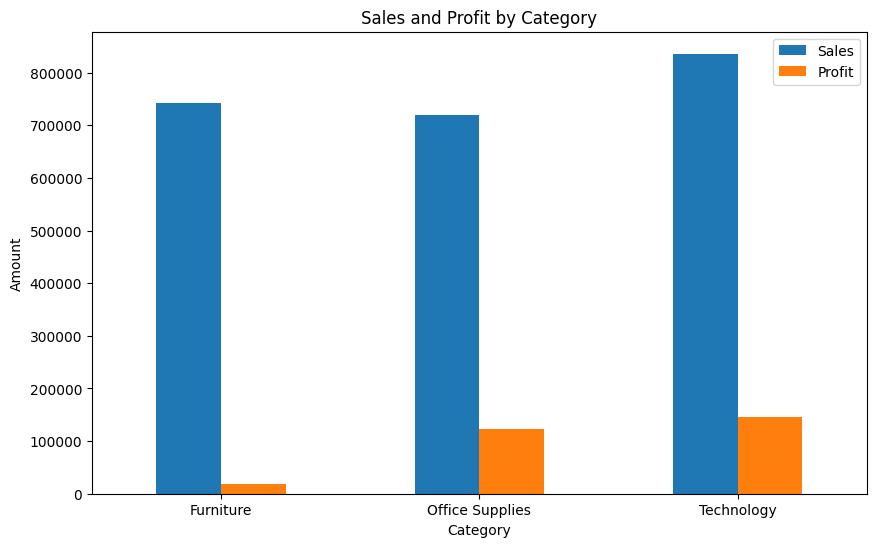

In [49]:
category_summary = df.groupby("category")[["sales", "profit"]].sum()

category_summary.plot(kind="bar", figsize=(10, 6))

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.show()

In [50]:
overall_profit_margin = (total_profit / total_sales) * 100

print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

Overall Profit Margin: 12.47 %


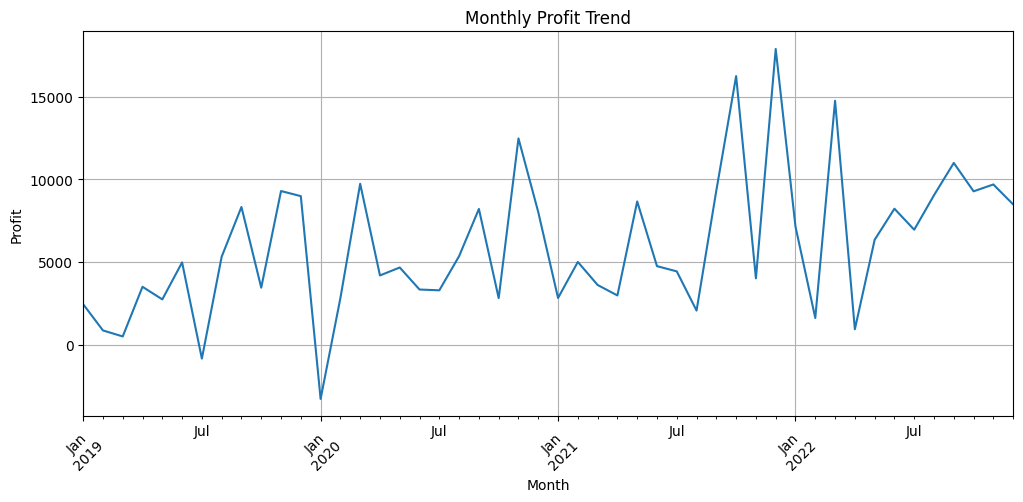

In [51]:
monthly_profit = df.groupby("month")["profit"].sum()
monthly_profit.plot(kind="line", figsize=(12, 5))

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [52]:
print("========== SALES DASHBOARD KPIs ==========")
print("Total Sales: $", round(total_sales, 2))
print("Total Profit: $", round(total_profit, 2))
print("Quantity Sold:", total_quantity)
print("Total Orders:", total_orders)
print("Average Order Value: $", round(average_order_value, 2))
print("Overall Profit Margin:", round(overall_profit_margin, 2), "%")

========== SALES DASHBOARD KPIs ==========
Total Sales: $ 2296919.49
Total Profit: $ 286409.08
Quantity Sold: 37871
Total Orders: 5009
Average Order Value: $ 458.56
Overall Profit Margin: 12.47 %


In [53]:
best_sales_category = sales_by_category.idxmax()
best_profit_category = profit_by_category.idxmax()
best_region = sales_by_region.idxmax()
best_product = top_products.idxmax()

print("========== BUSINESS INSIGHTS ==========")
print("Highest Sales Category:", best_sales_category)
print("Highest Profit Category:", best_profit_category)
print("Highest Sales Region:", best_region)
print("Top Product by Sales:", best_product)

========== BUSINESS INSIGHTS ==========
Highest Sales Category: Technology
Highest Profit Category: Technology
Highest Sales Region: West
Top Product by Sales: Canon imageCLASS 2200 Advanced Copier


In [54]:
!pip install -q plotly ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.3 MB/s eta 0:00:00


In [55]:
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

In [56]:
# ==========================================
# SALES & REVENUE ANALYSIS DASHBOARD
# ==========================================

import plotly.express as px
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Enable widgets in Google Colab
from google.colab import output
output.enable_custom_widget_manager()


# ==========================================
# CREATE FILTER WIDGETS
# ==========================================

region_filter = widgets.Dropdown(
    options=["All"] + sorted(df["region"].dropna().unique().tolist()),
    value="All",
    description="Region:"
)

category_filter = widgets.Dropdown(
    options=["All"] + sorted(df["category"].dropna().unique().tolist()),
    value="All",
    description="Category:"
)

dashboard_output = widgets.Output()


# ==========================================
# DASHBOARD FUNCTION
# ==========================================

def update_dashboard(region="All", category="All"):

    filtered_df = df.copy()

    # Apply Region Filter
    if region != "All":
        filtered_df = filtered_df[
            filtered_df["region"] == region
        ]

    # Apply Category Filter
    if category != "All":
        filtered_df = filtered_df[
            filtered_df["category"] == category
        ]


    # ==========================================
    # KPI CALCULATIONS
    # ==========================================

    filtered_sales = filtered_df["sales"].sum()
    filtered_profit = filtered_df["profit"].sum()
    filtered_quantity = filtered_df["quantity"].sum()
    filtered_orders = filtered_df["order_id"].nunique()

    if filtered_orders > 0:
        filtered_aov = filtered_sales / filtered_orders
    else:
        filtered_aov = 0

    if filtered_sales != 0:
        filtered_margin = (filtered_profit / filtered_sales) * 100
    else:
        filtered_margin = 0


    # ==========================================
    # MONTHLY SALES
    # ==========================================

    monthly = (
        filtered_df
        .groupby("month")["sales"]
        .sum()
        .reset_index()
    )

    monthly["month"] = monthly["month"].astype(str)


    # ==========================================
    # MONTHLY PROFIT
    # ==========================================

    monthly_profit_data = (
        filtered_df
        .groupby("month")["profit"]
        .sum()
        .reset_index()
    )

    monthly_profit_data["month"] = (
        monthly_profit_data["month"].astype(str)
    )


    # ==========================================
    # SALES BY CATEGORY
    # ==========================================

    category_data = (
        filtered_df
        .groupby("category")["sales"]
        .sum()
        .reset_index()
        .sort_values("sales", ascending=False)
    )


    # ==========================================
    # PROFIT BY REGION
    # ==========================================

    region_data = (
        filtered_df
        .groupby("region")["profit"]
        .sum()
        .reset_index()
        .sort_values("profit", ascending=False)
    )


    # ==========================================
    # TOP 10 PRODUCTS
    # ==========================================

    product_data = (
        filtered_df
        .groupby("product_name")["sales"]
        .sum()
        .reset_index()
        .sort_values("sales", ascending=False)
        .head(10)
        .sort_values("sales")
    )


    # ==========================================
    # DISPLAY DASHBOARD
    # ==========================================

    with dashboard_output:

        clear_output(wait=True)


        # ==========================================
        # TITLE
        # ==========================================

        display(
            HTML(
                """
                <h1 style="
                    text-align:center;
                    margin-bottom:20px;
                ">
                Sales & Revenue Analysis Dashboard
                </h1>
                """
            )
        )


        # ==========================================
        # KPI CARDS
        # ==========================================

        kpi_html = f"""
        <div style="
            display:flex;
            flex-wrap:wrap;
            gap:15px;
            justify-content:center;
            margin:20px 0;
        ">

            <div style="
                padding:20px;
                border:1px solid #ddd;
                border-radius:10px;
                width:160px;
                text-align:center;
            ">
                <h3>Total Sales</h3>
                <h2>${filtered_sales:,.2f}</h2>
            </div>

            <div style="
                padding:20px;
                border:1px solid #ddd;
                border-radius:10px;
                width:160px;
                text-align:center;
            ">
                <h3>Total Profit</h3>
                <h2>${filtered_profit:,.2f}</h2>
            </div>

            <div style="
                padding:20px;
                border:1px solid #ddd;
                border-radius:10px;
                width:160px;
                text-align:center;
            ">
                <h3>Quantity Sold</h3>
                <h2>{filtered_quantity:,}</h2>
            </div>

            <div style="
                padding:20px;
                border:1px solid #ddd;
                border-radius:10px;
                width:160px;
                text-align:center;
            ">
                <h3>Total Orders</h3>
                <h2>{filtered_orders:,}</h2>
            </div>

            <div style="
                padding:20px;
                border:1px solid #ddd;
                border-radius:10px;
                width:160px;
                text-align:center;
            ">
                <h3>Avg Order Value</h3>
                <h2>${filtered_aov:,.2f}</h2>
            </div>

            <div style="
                padding:20px;
                border:1px solid #ddd;
                border-radius:10px;
                width:160px;
                text-align:center;
            ">
                <h3>Profit Margin</h3>
                <h2>{filtered_margin:.2f}%</h2>
            </div>

        </div>
        """

        display(HTML(kpi_html))


        # ==========================================
        # CHART 1 - MONTHLY SALES
        # ==========================================

        fig1 = px.line(
            monthly,
            x="month",
            y="sales",
            markers=True,
            title="Monthly Sales Trend"
        )

        fig1.update_layout(
            xaxis_title="Month",
            yaxis_title="Sales",
            height=450
        )

        display(fig1)


        # ==========================================
        # CHART 2 - MONTHLY PROFIT
        # ==========================================

        fig2 = px.line(
            monthly_profit_data,
            x="month",
            y="profit",
            markers=True,
            title="Monthly Profit Trend"
        )

        fig2.update_layout(
            xaxis_title="Month",
            yaxis_title="Profit",
            height=450
        )

        display(fig2)


        # ==========================================
        # CHART 3 - SALES BY CATEGORY
        # ==========================================

        fig3 = px.bar(
            category_data,
            x="category",
            y="sales",
            title="Sales by Category"
        )

        fig3.update_layout(
            xaxis_title="Category",
            yaxis_title="Sales",
            height=450
        )

        display(fig3)


        # ==========================================
        # CHART 4 - PROFIT BY REGION
        # ==========================================

        fig4 = px.bar(
            region_data,
            x="region",
            y="profit",
            title="Profit by Region"
        )

        fig4.update_layout(
            xaxis_title="Region",
            yaxis_title="Profit",
            height=450
        )

        display(fig4)


        # ==========================================
        # CHART 5 - TOP 10 PRODUCTS
        # ==========================================

        fig5 = px.bar(
            product_data,
            x="sales",
            y="product_name",
            orientation="h",
            title="Top 10 Products by Sales"
        )

        fig5.update_layout(
            xaxis_title="Sales",
            yaxis_title="Product",
            height=550
        )

        display(fig5)


# ==========================================
# FILTER UPDATE FUNCTION
# ==========================================

def refresh_dashboard(change=None):

    update_dashboard(
        region=region_filter.value,
        category=category_filter.value
    )


# ==========================================
# CONNECT FILTERS
# ==========================================

region_filter.observe(
    refresh_dashboard,
    names="value"
)

category_filter.observe(
    refresh_dashboard,
    names="value"
)


# ==========================================
# DISPLAY FILTERS
# ==========================================

display(
    HTML(
        """
        <h2 style="text-align:center;">
        Dashboard Filters
        </h2>
        """
    )
)

display(
    widgets.HBox(
        [region_filter, category_filter]
    )
)


# ==========================================
# DISPLAY DASHBOARD
# ==========================================

display(dashboard_output)


# ==========================================
# START DASHBOARD
# ==========================================

update_dashboard()

Output()

# Sales & Revenue Analysis Dashboard

## 1. Project Overview

This project analyzes sales data to identify trends, top-performing products,
profitable categories, and regional performance.

## 2. Key Features

1. Data import from CSV
2. Data cleaning and duplicate removal
3. KPI calculation
4. Sales and profit analysis
5. Monthly sales and profit trends
6. Top 10 products by sales
7. Category-level analysis
8. Regional analysis
9. Interactive Region and Category filters
10. Interactive Plotly visualizations

## 3. KPIs

1. Total Sales: $2,296,919.49
2. Total Profit: $286,409.08
3. Quantity Sold: 37,871
4. Total Orders: 5,009
5. Average Order Value: $458.56

## 4. Tools & Technologies

1. Python
2. Pandas
3. Matplotlib
4. Plotly
5. IPyWidgets
6. Google Colab
7. Kaggle Dataset

## Business Insights

1. **Technology** is the highest-performing category in terms of both sales and profit.

2. **West** is the leading region by total sales.

3. **Canon imageCLASS 2200 Advanced Copier** is the top-performing product by sales.

4. The **monthly sales trend** helps identify changes in sales performance over time.

5. Comparing sales with profit provides a better understanding of overall business performance.

6. The **Region** and **Category** filters allow users to interactively analyze specific parts of the dataset.


## Conclusion

The Sales & Revenue Analysis Dashboard provides an interactive overview of sales, profit, products, categories, and regional performance.

The project demonstrates practical skills in data cleaning, KPI calculation, data analysis, visualization, and interactive dashboard development using Python, Pandas, Plotly, and IPyWidgets.

The dashboard can help users quickly identify sales trends, high-performing products, profitable categories, and regional performance.
